In [351]:
import pandas as pd
import numpy as np

In [352]:
# read datasdet using pandas
df=pd.read_csv('used_car_dataset.csv')

In [353]:
df.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


In [354]:
df.shape

(9582, 11)

In [355]:
# information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9582 entries, 0 to 9581
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Brand         9582 non-null   object
 1   model         9582 non-null   object
 2   Year          9582 non-null   int64 
 3   Age           9582 non-null   int64 
 4   kmDriven      9535 non-null   object
 5   Transmission  9582 non-null   object
 6   Owner         9582 non-null   object
 7   FuelType      9582 non-null   object
 8   PostedDate    9582 non-null   object
 9   AdditionInfo  9582 non-null   object
 10  AskPrice      9582 non-null   object
dtypes: int64(2), object(9)
memory usage: 823.6+ KB


In [356]:
df.nunique()

Brand             39
model            400
Year              32
Age               32
kmDriven        1910
Transmission       2
Owner              2
FuelType           3
PostedDate        12
AdditionInfo    7307
AskPrice        1330
dtype: int64

In [357]:
df.describe()

,Year,Age
count,9582.000000,9582.000000
mean,2016.361094,7.638906
std,4.087226,4.087226
min,1986.000000,0.000000
25%,2014.000000,5.000000
50%,2017.000000,7.000000
75%,2019.000000,10.000000
max,2024.000000,38.000000


# Handling Missing Values

In [358]:
df.isnull().sum()

Brand            0
model            0
Year             0
Age              0
kmDriven        47
Transmission     0
Owner            0
FuelType         0
PostedDate       0
AdditionInfo     0
AskPrice         0
dtype: int64

#  Explore Data Characteristics

### percentage distribution

In [359]:
brand_distribution = df['Brand'].value_counts(normalize=True) * 100
brand_distribution

Brand
Maruti Suzuki    28.386558
Hyundai          15.957003
Honda             8.369860
Toyota            8.108954
Mahindra          5.844291
Mercedes-Benz     4.195366
Tata              4.059695
BMW               3.569192
Volkswagen        3.318723
Audi              2.755166
Ford              2.556877
Renault           2.504696
Skoda             1.909831
Kia               1.680234
Chevrolet         0.928825
MG                0.834899
Nissan            0.782718
Jeep              0.772281
Land Rover        0.740973
Volvo             0.500939
Mini              0.427886
Jaguar            0.354832
Porsche           0.250470
Fiat              0.229597
Datsun            0.229597
Lexus             0.208725
Mitsubishi        0.187852
Isuzu             0.104362
Force             0.062617
Ambassador        0.031309
Rolls-Royce       0.020872
Bajaj             0.020872
Opel              0.020872
Ssangyong         0.020872
Aston Martin      0.010436
ICML              0.010436
Ashok             0.01

In [360]:
model_distribution = df['model'].value_counts(normalize=True) * 100
model_distribution

model
City                3.443957
Wagon-R             3.245669
Swift               2.953454
Creta               2.713421
Ertiga              2.598622
                      ...   
H5x                 0.010436
Punch               0.010436
Tiguan All Space    0.010436
Cedia               0.010436
Gran Turismo        0.010436
Name: proportion, Length: 400, dtype: float64

In [361]:
# Step 1: Remove unwanted characters from the 'kmDriven' column
df["kmDriven"] = (
    df["kmDriven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
)

# Step 2: Convert the cleaned strings to numeric values
df["kmDriven"] = pd.to_numeric(df["kmDriven"], errors="coerce") # error="coerce" -> Invalid values (if any) are converted to NaN

# Step 3: Fill missing values with the mean of the column
df["kmDriven"] = df["kmDriven"].fillna(df["kmDriven"].mean())

# Step 4: Convert to integer type
df["kmDriven"] = df["kmDriven"].astype("int64")

In [362]:
# Step 1: Remove unwanted characters from the 'kmDriven' column
df["AskPrice"] = (
    df["AskPrice"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
)

# Step 2: Convert the cleaned strings to numeric values
df["AskPrice"] = pd.to_numeric(df["AskPrice"], errors="coerce") # error="coerce" -> Invalid values (if any) are converted to NaN

# Step 3: Fill missing values with the mean of the column
df["AskPrice"] = df["AskPrice"].fillna(df["AskPrice"].mean())

# Step 4: Convert to integer type
df["AskPrice"] = df["AskPrice"].astype("int64")

df.rename(columns={"AskPrice": "Price"}, inplace=True)

In [363]:
df.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,Price
0,Honda,City,2001,23,98000,Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...",195000
1,Toyota,Innova,2009,15,190000,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",375000
2,Volkswagen,VentoTest,2010,14,77246,Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999
3,Maruti Suzuki,Swift,2017,7,83500,Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,565000
4,Maruti Suzuki,Baleno,2019,5,45000,Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000


In [364]:
# Drop Irrelavent Columns
df = df.drop(columns=['Year','PostedDate','AdditionInfo'])

# Visualize Data Relationships

In [365]:
import seaborn as sns
import matplotlib.pyplot as plt

### 1.The Target Distribution --> Is your price data skewed?

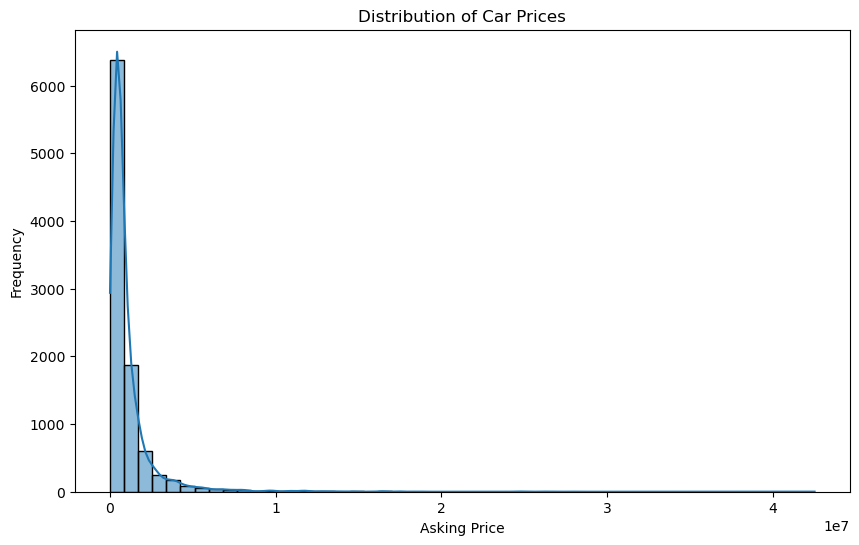

In [366]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, bins=50)
plt.title('Distribution of Car Prices')
plt.xlabel('Asking Price')
plt.ylabel('Frequency')
plt.show()

### 2.The Correlation Heatmap --> What drives the price?

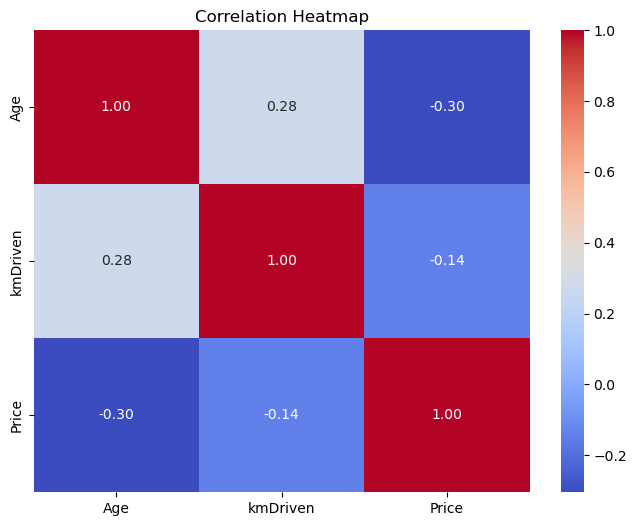

In [367]:
# Select only numerical columns for the correlation matrix
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### 3.Categorical Impact --> Do certain brands cost more?

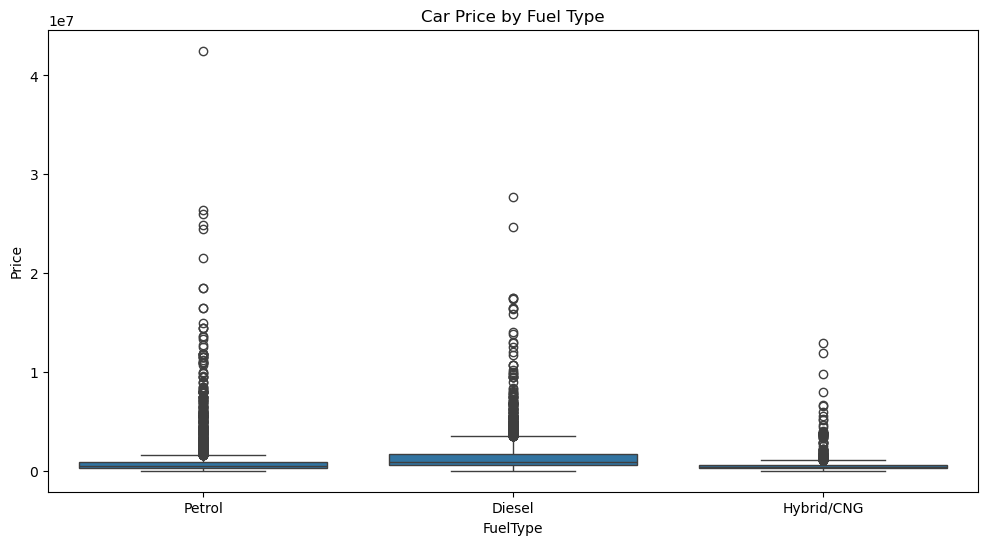

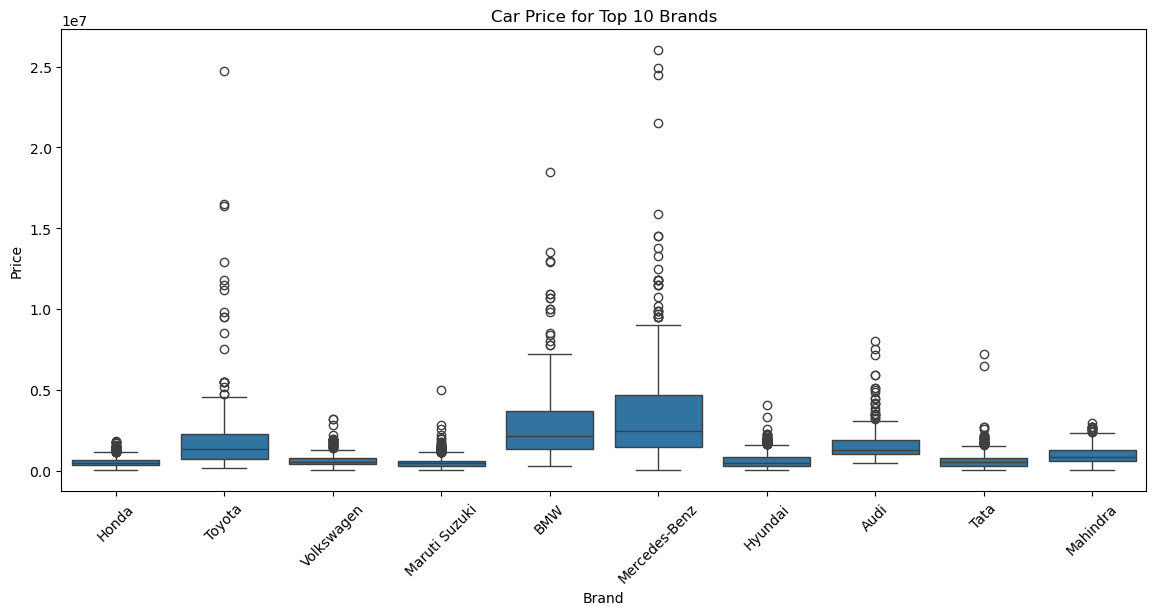

In [368]:
plt.figure(figsize=(12, 6))
# Boxplot for Fuel Type vs Price
sns.boxplot(x='FuelType', y='Price', data=df)
plt.title('Car Price by Fuel Type')
plt.show()

# Boxplot for Top 10 Brands vs Price
plt.figure(figsize=(14, 6))
top_brands = df['Brand'].value_counts().index[:10] # Get the top 10 most common brands
sns.boxplot(x='Brand', y='Price', data=df[df['Brand'].isin(top_brands)])
plt.title('Car Price for Top 10 Brands')
plt.xticks(rotation=45)
plt.show()

### 4.Numerical Impact --> How fast does price drop with age?

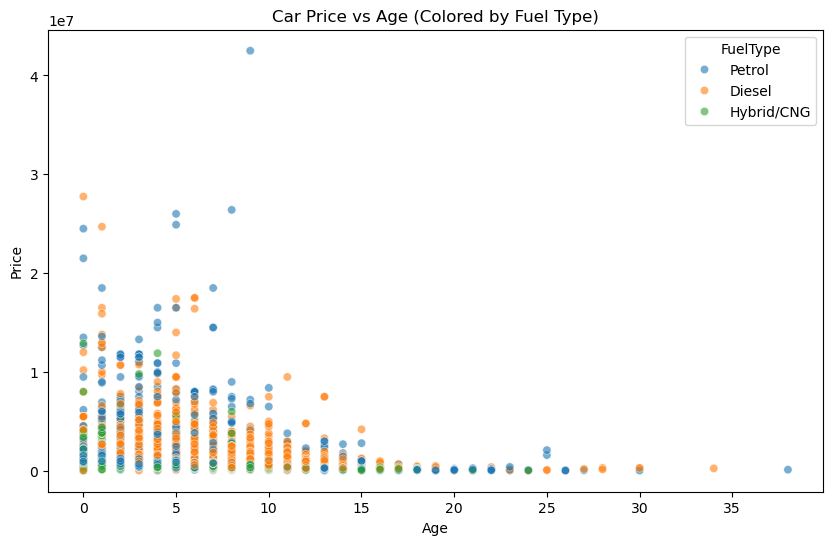

In [369]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Price', hue='FuelType', data=df, alpha=0.6)
plt.title('Car Price vs Age (Colored by Fuel Type)')
plt.show()

### Transforming Text into Numbers (Encoding)

In [370]:
# our "Brand " and "model" columns  has large number of unique variety values.
df['Brand_enc']=df['Brand'].map(df['Brand'].value_counts(normalize=True))

df['Model_enc']=df['model'].map(df['model'].value_counts(normalize=True))

In [371]:
df.drop(columns=["Brand","model"],inplace=True)

In [372]:
# Transmission Column
df["Transmission"] = df["Transmission"].map({"Manual": 0, "Automatic": 1})

# Owner Column
df["Owner"] = df["Owner"].map({"first": 0, "second": 1})

# FuelType Column
df["FuelType"] = df["FuelType"].map({"Diesel": 0, "Petrol": 1, "Hybrid/CNG": 2})

In [373]:
df.head()

,Age,kmDriven,Transmission,Owner,FuelType,Price,Brand_enc,Model_enc
0,23,98000,0,1,1,195000,0.083699,0.034440
1,15,190000,0,1,0,375000,0.081090,0.012732
2,14,77246,0,0,0,184999,0.033187,0.008245
3,7,83500,0,1,0,565000,0.283866,0.029535
4,5,45000,1,0,1,685000,0.283866,0.018681


# Model Training

### Step 1 : Split Features (X) from Target (y)

In [374]:
# extracting X and Y

X = df.drop(columns=['Price']) # Everything Except The Price Columns
y = np.log(df['Price'])         # Only the Price Columns

# apply a log transformation to stabilize variance, normalize skewed distributions

print("Features Dataset Shape:", X.shape)
print("Target Dataset Shape:", y.shape)

Features Dataset Shape: (9582, 7)
Target Dataset Shape: (9582,)


### Step 2 : The Train-Test Split 

In [375]:
# Train-Test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Features shape:", X_train.shape)
print("Testing Features shape:", X_test.shape)

Training Features shape: (7665, 7)
Testing Features shape: (1917, 7)


### Step 3 : Training the Random Forest Regressor

In [378]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

# step1 Create the Model
rf_model = RandomForestRegressor(random_state=42)

# step2 Train the Model
rf_model.fit(X_train,y_train)

# step3 Give data to model for prediction
prediction = rf_model.predict(X_test)

# step4 Check the result

R2_score = r2_score(y_test,prediction)
MeanAE_score = mean_absolute_error(y_test,prediction)
MeanSE_score = mean_squared_error(y_test, prediction)

print('R2 score:',R2_score)
print('MAE:',MeanAE_score)
print("MSE:",MeanSE_score)

R2 score: 0.8719920340364924
MAE: 0.20905159609351678
MSE: 0.1085893617341503


In [380]:
import joblib

# 1. Export the Model
joblib.dump(rf_model, 'car_price_model.joblib')

# 2. Save the exact column names!
joblib.dump(X.columns, 'expected_columns.joblib')
    
print("Model and columns exported successfully with joblib!")

Model and columns exported successfully with joblib!
